In [1]:
import pandas as pd
import joblib    # joblib package used to save and use heavy data
from sklearn.metrics import(
        accuracy_score,
        recall_score,
        precision_score,
        f1_score,
        roc_auc_score,
        confusion_matrix,
        classification_report
)


In [2]:
model = joblib.load("../models/physionet_lightgbm.pkl")
print("model loaded succesfully")

model loaded succesfully


In [3]:
external = pd.read_csv("../data/processed/external_feature_dataset.csv")
print(external.shape)
external.head()

(40336, 201)


,HR_mean,HR_min,HR_max,HR_std,HR_last,O2Sat_mean,O2Sat_min,O2Sat_max,O2Sat_std,O2Sat_last,...,HospAdmTime_min,HospAdmTime_max,HospAdmTime_std,HospAdmTime_last,ICULOS_mean,ICULOS_min,ICULOS_max,ICULOS_std,ICULOS_last,SepsisLabel
0,101.571429,76.0,117.0,9.594378,84.0,91.477273,85.0,100.0,3.460667,85.0,...,-0.03,-0.03,3.502025e-18,-0.03,27.5,1,54,15.732133,54,0
1,60.954545,54.0,94.0,8.144395,55.0,97.000000,94.0,100.0,2.138090,95.0,...,-98.60,-98.60,2.906048e-14,-98.60,12.0,1,23,6.782330,23,0
2,79.611111,68.0,93.0,6.714036,78.0,95.431818,91.0,99.0,1.655122,97.0,...,-1195.71,-1195.71,0.000000e+00,-1195.71,24.5,1,48,14.000000,48,0
3,102.444444,93.0,113.0,6.337212,NaN,98.203704,95.5,100.0,1.449531,NaN,...,-8.77,-8.77,1.807799e-15,-8.77,15.0,1,29,8.514693,29,0
4,73.916667,61.0,88.0,7.586697,NaN,97.500000,96.0,99.0,0.741620,NaN,...,-0.05,-0.05,7.012323e-18,-0.05,25.5,2,49,14.000000,49,0


In [4]:
###features used by trained physionet model
model_feature = model.feature_name_
### remove target from external dataset
external_features = external.drop(columns=["SepsisLabel"])
print("model expects:", len(model_feature), "features")
print("external data set has :", len(external_features.columns), "features")
### missing feature from external dataset
missing_features = set(model_feature) - set(external_features.columns)
##W additional information present in  external dataset
extra_features = set(external_features.columns) - set(model_feature)
print("\nmissing features:", len(missing_features))
print(missing_features)
print("\nextra features:", len(extra_features))
print(extra_features)

model expects: 200 features
external data set has : 200 features

missing features: 0
set()

extra features: 0
set()


In [5]:
X_external = external[model_feature]
y_external = external["SepsisLabel"]
print("X_external shape :" , X_external.shape )
print("y_external shape :", y_external.shape)

X_external shape : (40336, 200)
y_external shape : (40336,)


In [6]:
# prediction
y_pred = model.predict(X_external)
#probability
y_prob = model.predict_proba(X_external)[:,1]
print("prediction succesfull")
print(" prediction shape :", y_pred.shape)
print("probability shape :", y_prob.shape)

prediction succesfull
 prediction shape : (40336,)
probability shape : (40336,)


In [7]:
print(" EXTERNAL VALIDATION RESULTS ")

print("\nConfusion Matrix:")
cm = confusion_matrix(y_external, y_pred)
print(cm)

print("\nClassification Report:")
print(classification_report(y_external, y_pred, digits=4))

print("Accuracy :", accuracy_score(y_external, y_pred))
print("Precision:", precision_score(y_external, y_pred))
print("Recall   :", recall_score(y_external, y_pred))
print("F1 Score :", f1_score(y_external, y_pred))
print("AUROC    :", roc_auc_score(y_external, y_prob))

 EXTERNAL VALIDATION RESULTS 

Confusion Matrix:
[[36978   426]
 [  638  2294]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9830    0.9886    0.9858     37404
           1     0.8434    0.7824    0.8117      2932

    accuracy                         0.9736     40336
   macro avg     0.9132    0.8855    0.8988     40336
weighted avg     0.9729    0.9736    0.9732     40336

Accuracy : 0.9736215787385958
Precision: 0.8433823529411765
Recall   : 0.7824010914051842
F1 Score : 0.8117480537862704
AUROC    : 0.9570255926112182


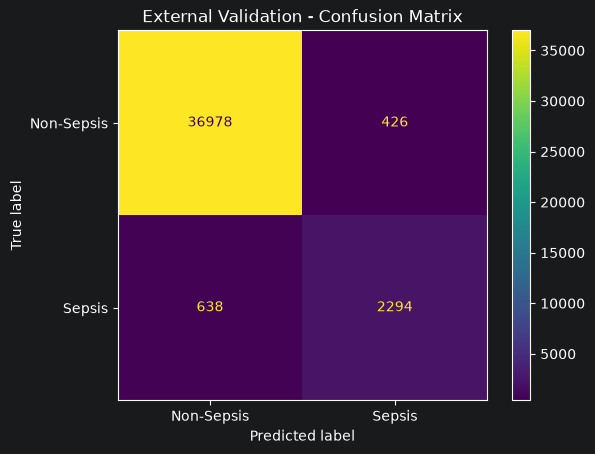

In [12]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(
    confusion_matrix = cm,
    display_labels = ["Non-Sepsis","Sepsis"]
)
disp.plot()
plt.title("External Validation - Confusion Matrix")
plt.show()

In [13]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)
import pandas as pd

thresholds = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]  # treshhold is used to increase the sensitivity off the model to increase the prediction of the fn as per sepsis

results = []

for threshold in thresholds:

    y_pred_threshold = (y_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_external,
        y_pred_threshold
    ).ravel()

    results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_external, y_pred_threshold),
        "Recall": recall_score(y_external, y_pred_threshold),
        "F1": f1_score(y_external, y_pred_threshold),
        "False Positives": fp,
        "False Negatives": fn
    })

threshold_results = pd.DataFrame(results)

threshold_results

,Threshold,Precision,Recall,F1,False Positives,False Negatives
0,0.10,0.650313,0.849932,0.736842,1340,440
1,0.15,0.715162,0.834925,0.770417,975,484
2,0.20,0.755869,0.823670,0.788314,780,517
3,0.25,0.775000,0.814120,0.794079,693,545
4,0.30,0.794562,0.807299,0.800880,612,565
5,0.35,0.812414,0.803547,0.807956,544,576
6,0.40,0.822990,0.796044,0.809293,502,598
7,0.45,0.832734,0.789563,0.810574,465,617
8,0.50,0.843382,0.782401,0.811748,426,638


In [14]:
# False Positive Rate (FPR)

tn, fp, fn, tp = confusion_matrix(
    y_external,
    y_pred
).ravel()

fpr = fp / (fp + tn)

print("False Positive Rate :", fpr)
print("False Positive Rate (%):", fpr * 100)

print("\nFalse Positives:", fp)
print("True Negatives :", tn)  

False Positive Rate : 0.011389156239974335
False Positive Rate (%): 1.1389156239974334

False Positives: 426
True Negatives : 36978
